In [1]:
import torch, torchvision # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split, GroupKFold, StratifiedKFold

from PIL import Image
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json, math, datetime, random, gc, ast
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from time import time
from utils.index import *
from tqdm import tqdm

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import nms

from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SequentialSampler

from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [2]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU

2.7.1+cu118
True
Quadro P6000


In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    np.random.default_rng(seed=seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print('random seed done')


OPTIONS = json.loads(open('../Task/info.json', 'r').read())
TRIAL   = OPTIONS.get('trial', 0)

seed_everything(42 + TRIAL)
OPTIONS

random seed done


{'network': 'dbrnet',
 'dataset': 'dataset_74_wu',
 'img_size': None,
 'normalize': True,
 'lr': 0.001,
 'loss': 'dice_focal',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 32,
 'ema': False,
 'epochs': 100,
 'n_trials': 1,
 'trial': 0}

In [4]:
if OPTIONS.get('network') == 'macnn':
    torch.backends.cudnn.deterministic = False

IMG_SIZE   = OPTIONS.get('img_size')
BATCH_SIZE = OPTIONS.get('batch_size')
IMG_SIZE, BATCH_SIZE

(None, 2)

In [5]:
DATABASE = f'../Dataset/{OPTIONS.get("dataset")}/DataBase.csv'
df       = pd.read_csv(DATABASE)
IMG_SIZE = ast.literal_eval(df['shape'].iloc[0])

# O DataBase.csv TEM DE ESTAR NA NORMALIZAÇÃO QUE A RODADA PEDE (SEM A COLUNA, É O MIN-MAX DE SEMPRE)
FORMATTED = df['normalize'].iloc[0] if 'normalize' in df else True
if FORMATTED != OPTIONS.get('normalize', True):
    raise ValueError(f'{DATABASE} está com normalize={FORMATTED} e a rodada pede normalize={OPTIONS.get("normalize", True)}: rode o Format do dataset com este info.json')

print(f'{DATABASE}: {len(df)} volumes de shape {IMG_SIZE}')
print(df.img_path.iloc[0])
df

../Dataset/dataset_74_wu/DataBase.csv: 330 volumes de shape (128, 128, 128)
/home/grva-mint/Projects/Falhas/Dataset/dataset_74/images/img_0000.npy


,id,img_min,img_max,img_mean,img_std,msk_min,msk_max,shape,img_path,mask_path,normalize
0,img_0000.npy,0.0,1.0,0.529913,0.146943,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True
1,img_0001.npy,0.0,1.0,0.503019,0.121774,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True
2,img_0002.npy,0.0,1.0,0.469683,0.116922,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True
3,img_0003.npy,0.0,1.0,0.524412,0.117401,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True
4,img_0004.npy,0.0,1.0,0.524728,0.098068,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True
...,...,...,...,...,...,...,...,...,...,...,...
325,95.npy,0.0,1.0,0.491377,0.109896,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True
326,96.npy,0.0,1.0,0.474650,0.088855,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True
327,97.npy,0.0,1.0,0.454404,0.094104,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True
328,98.npy,0.0,1.0,0.474008,0.087315,0.0,1.0,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...,True


In [6]:
MULTICLASS = False
classes    = 1
classes

1

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


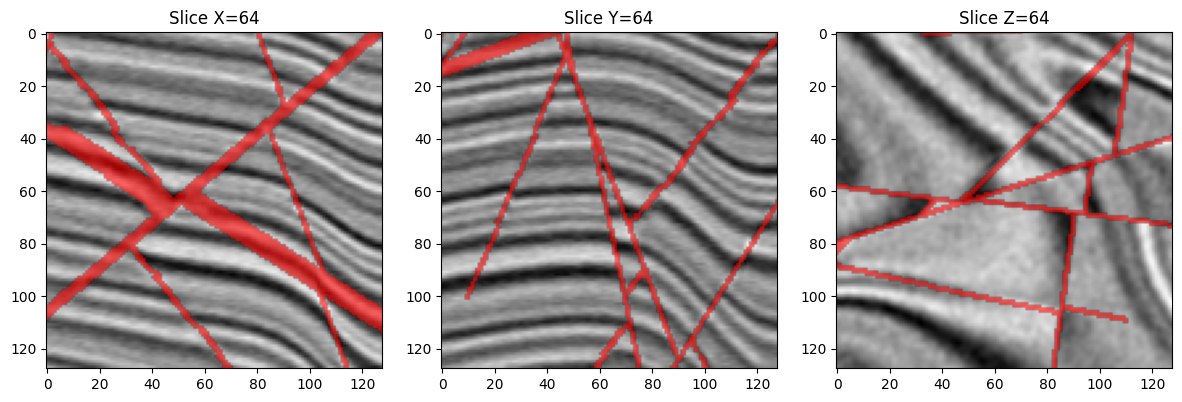

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


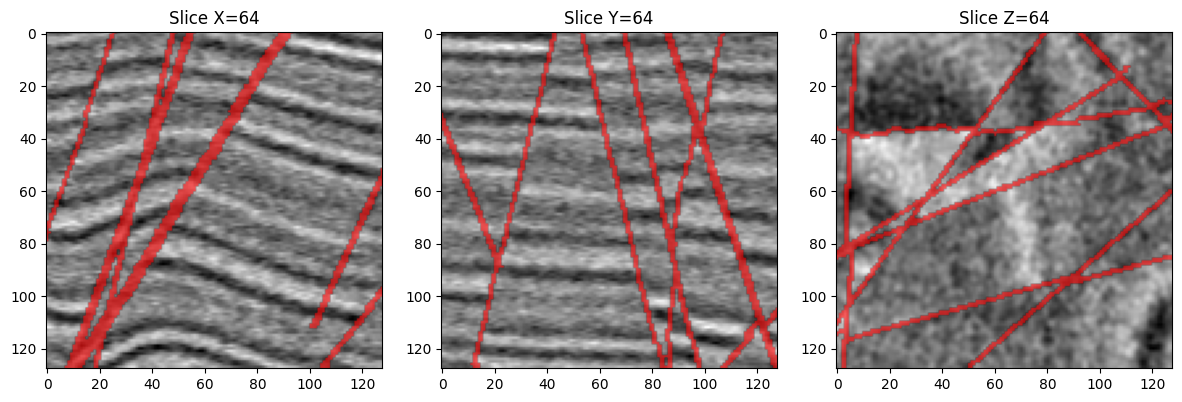

img: (np.float32(0.0), np.float32(1.0))
msk: (np.uint8(0), np.uint8(1))


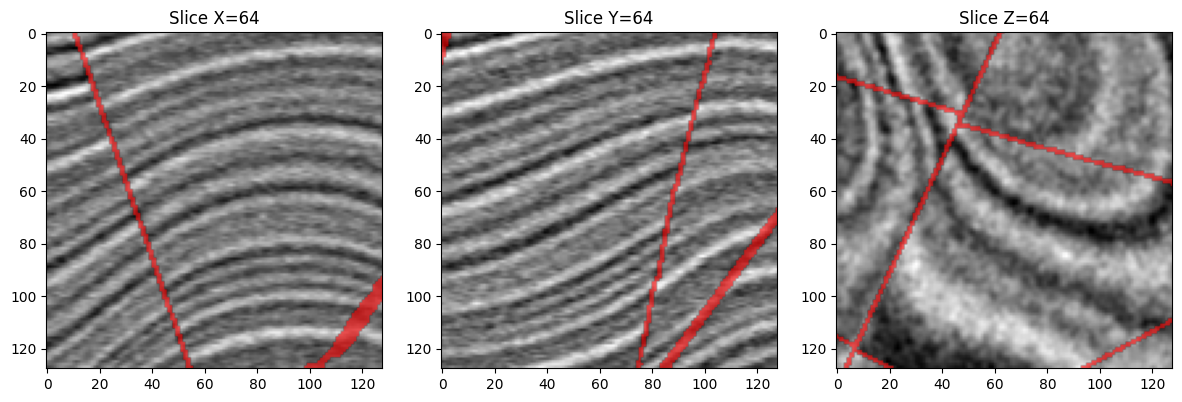

In [7]:
for index in range(3):
    img, msk = np.load(df.iloc[index].img_path), np.load(df.iloc[index].mask_path)
    print(f'img: {np.min(img), np.max(img)}')
    print(f'msk: {np.min(msk), np.max(msk)}')
    showTile(img=img, mask=msk)

# SPLITS DOS DADOS

- O split vai para o `division` do `info.json` salvo (`val_size`, `test_size`, `n_images`); o `processing` fica sendo o `Task/info.json` exatamente como veio, para copiar e reproduzir.

In [8]:
VAL_SIZE  = 0.045454545454545456
TEST_SIZE = 0.045454545454545456
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [9]:
temp_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=42)
train_df, val_df = train_test_split(temp_df, test_size=VAL_SIZE, random_state=42)
del temp_df

DIVISION = {
    'val_size': VAL_SIZE,
    'test_size': TEST_SIZE,
    'n_images': {'total': len(df), 'train': len(train_df), 'val': len(val_df), 'test': len(test_df)},
}
DIVISION

{'val_size': 0.047619047619047616,
 'test_size': 0.045454545454545456,
 'n_images': {'total': 330, 'train': 300, 'val': 15, 'test': 15}}

# AUMENTAÇÃO

- O `augmentations` do `info.json` liga a aumentação do treino (`Transforms/index.py`); `null` ou ausente treina com os tiles como estão, igual a antes.
- O sorteio é feito no `DataLoader`, tile a tile e de novo a cada época, com a semente `(42 + trial, época, índice)`: o mesmo treino repete a mesma aumentação com qualquer número de workers, sem tocar no gerador global (o `shuffle` e os pesos iniciais não mudam).
- `n_aug` (1, como nos autores) é quantas variações de cada tile entram por época: a época passa a ter `n_aug` × tiles amostras, cada uma com o seu sorteio.
- As operações rodam na ordem em que aparecem no JSON e só no treino; validação e teste ficam como estão.
- Com `crop`, a rede é montada na janela do recorte e prediz o tile inteiro de validação e teste por janela deslizante (`overlap`, `mode`, lote de `batch_size` janelas): o IoU continua sendo do tile inteiro. O `img_size` do modelo salvo é a janela, que o `3 - Predict` e o Marlim já usam.

In [10]:
from Transforms.index import Transforms

In [11]:
transforms = Transforms(OPTIONS.get('augmentations'), seed=42 + TRIAL, batch=BATCH_SIZE)
WINDOW     = transforms.window or IMG_SIZE

print(f'tile {IMG_SIZE} | janela da rede {WINDOW} | n_aug {transforms.copies}')
pd.DataFrame(transforms.options).T.fillna('')

tile (128, 128, 128) | janela da rede (128, 128, 128) | n_aug 1


""


# MODELO

In [12]:
from Network.index import ModelNetwork

In [13]:
model_options = {
    'network': OPTIONS.get('network'),
    'img_size': WINDOW,
    'classes': classes,
    'channels': 1,
    'dropout': OPTIONS.get('dropout'),
    'num_filters': OPTIONS.get('num_filters'),
    'lr': OPTIONS.get('lr'),
}

print(model_options)
network = ModelNetwork(**model_options)
network.model

{'network': 'dbrnet', 'img_size': (128, 128, 128), 'classes': 1, 'channels': 1, 'dropout': 0.1, 'num_filters': 32, 'lr': 0.001}


Unet3D_V2(
  (enc1): EncoderBlock(
    (conv_block): Conv3DBlock(
      (conv1): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act1): LeakyReLU(negative_slope=0.1, inplace=True)
      (conv2): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act2): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (pool): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout3d(p=0.025, inplace=False)
  )
  (enc2): EncoderBlock(
    (conv_block): Conv3DBlock(
      (conv1): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act1): LeakyReLU(negative_slope=0.1, inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1),

In [14]:
network.classes

1

# DATASET

In [15]:
from torch.utils.data import Dataset

In [16]:
class CustomDataset(Dataset):
    def __init__(self, df, multiclass=False, transforms=None):
        self.df = df.reset_index(drop=True)
        self.multiclass = multiclass
        self.transforms  = transforms
        self.epoch      = 0

    # COM n_aug CADA TILE ENTRA n_aug VEZES NA ÉPOCA, CADA VEZ COM O SEU ÍNDICE E PORTANTO O SEU SORTEIO
    def __len__(self):
        return len(self.df) * (self.transforms.copies if self.transforms else 1)

    def __getitem__(self, index):
        row  = self.df.iloc[index % len(self.df)]
        img  = np.load(row.img_path).astype(np.float32)
        mask = np.load(row.mask_path).astype(np.float32)

        if self.transforms:
            img, mask = self.transforms.apply(img, mask, epoch=self.epoch, index=index)

        img_tensor  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
        return (img_tensor, mask_tensor)


trainDataset=CustomDataset(
    df=train_df, 
    multiclass=MULTICLASS,
    transforms=transforms
)

valDataset=CustomDataset(
    df=val_df, 
    multiclass=MULTICLASS
)

testDataset=CustomDataset(
    df=test_df, 
    multiclass=MULTICLASS
)

# DATA LOADER

In [17]:
from torch.utils.data import DataLoader

In [18]:
NUM_WORKERS = 2

trainLoader = DataLoader(
    trainDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

valLoader = DataLoader(
    valDataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

testLoader = DataLoader(
    testDataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

xTrain Shape:  (128, 128, 128)
yTrain Shape:  (128, 128, 128)
xTrain Range:  (0.0, 1.0)
yTrain Unique: [0 1]


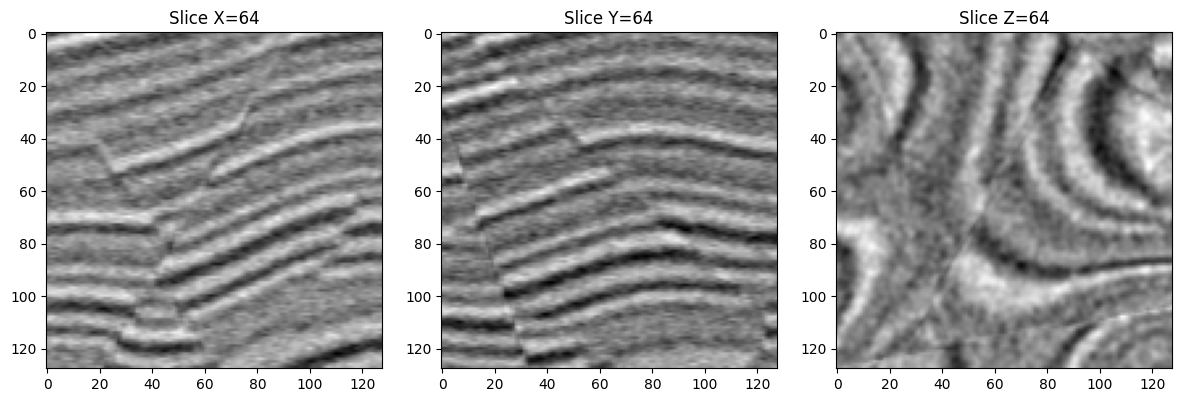

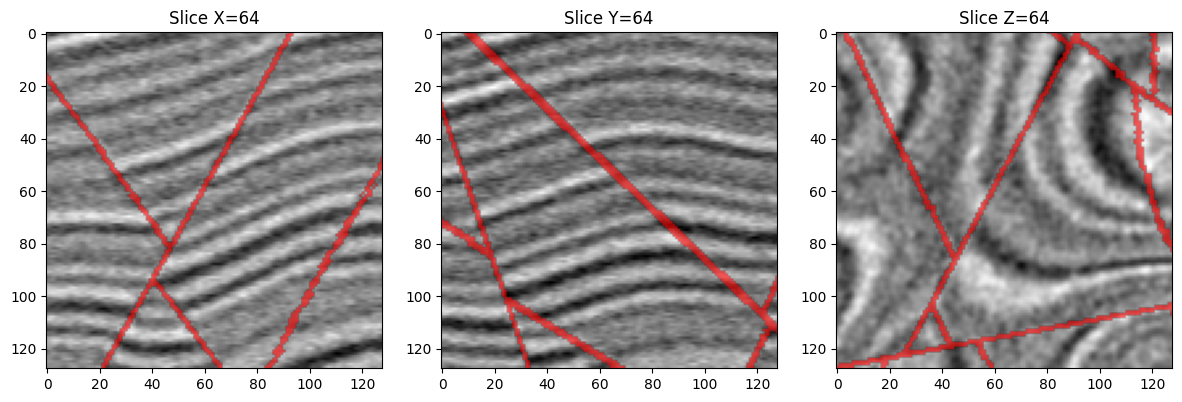

In [19]:
images, masks = next(iter(trainLoader))
img = images[0].squeeze().cpu().numpy()
msk = masks[0].squeeze().cpu().numpy()

print('xTrain Shape: ', img.shape)
print('yTrain Shape: ', msk.shape)
print('xTrain Range: ', (float(np.min(img)), float(np.max(img))))
print('yTrain Unique:', np.unique(msk).astype(int))

showTile(img)
showTile(img=img, mask=msk)

# TREINAMENTO

### Losses

In [20]:
from Losses.index import Losses
from EarlyStopping.index import EarlyStopping
from EMA.index import ModelEMA
from torch import amp
gc.collect()

19336

In [21]:
selected_loss = OPTIONS.get('loss')
loss = Losses(selected_loss, multiclass=network.multiclass)
loss

DiceFocalLoss(
  (_loss): DiceFocalLoss(
    (dice): DiceLoss()
    (focal): FocalLoss()
  )
)

### Scheduler

- `plateau`: corta o `lr` pela metade quando o `val_loss` fica 10 épocas sem melhorar, uma vez por época.
- `cosine`: a agenda dos autores da ResACEUnet — sobe linear de 1e-6 até o `lr` nas 10 primeiras épocas e desce em cosseno até 1e-7 no fim das `epochs`, andando a cada batch.

In [22]:
from torch.optim.lr_scheduler import LambdaLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [23]:
# AQUECIMENTO + COSSENO DA RESACEUNET (ZU ET AL. 2024, SEÇÃO 3.2): SOBE LINEAR DE 1e-6 ATÉ O lr NAS 10 PRIMEIRAS ÉPOCAS
# (warmup_epochs DO config.yaml DOS AUTORES) E DESCE EM COSSENO ATÉ 1e-7 NO FIM DAS epochs, UM PASSO POR BATCH
class CosineScheduler(LambdaLR):
    WARMUP = 10
    START  = 1e-6
    END    = 1e-7

    def __init__(self, optimizer, epochs, steps):
        self.peak   = optimizer.param_groups[0].get('initial_lr', optimizer.param_groups[0]['lr'])
        self.warmup = self.WARMUP * steps
        self.total  = epochs * steps
        super().__init__(optimizer, self.factor)

    def factor(self, step):
        if step < self.warmup:
            return (self.START + (self.peak - self.START) * step / self.warmup) / self.peak

        progress = min((step - self.warmup) / max(self.total - self.warmup, 1), 1.0)
        return (self.END + (self.peak - self.END) * 0.5 * (1.0 + math.cos(math.pi * progress))) / self.peak


class Scheduler:
    def __new__(cls, selected, optimizer, epochs=100, steps=1):
        if selected == 'plateau':
            return ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        
        if selected == 'cosine':
            return CosineScheduler(optimizer, epochs=epochs, steps=steps)
        
        return None


scheduler = OPTIONS.get('scheduler')
Scheduler(scheduler, network.optimizer)

### Trainer

In [24]:
class Trainer:
    def __init__(self, network, loss, epochs, scheduler='plateau', ema=False, transforms=None, use_amp=False, patience=15):
        self.network  = network
        self.loss     = loss
        self.epochs   = epochs
        self.img_size = network.img_size 
        
        self.scheduler = Scheduler(scheduler, self.network.optimizer, epochs=epochs, steps=len(trainLoader))
        self.stepwise  = isinstance(self.scheduler, CosineScheduler)
        self.early_stopping = EarlyStopping(patience=patience, mode='max', min_delta=1e-4)

        self.use_amp = use_amp
        self.scaler  = amp.GradScaler('cuda', enabled=self.use_amp)

        # COM EMA A VALIDACAO, O EARLY STOPPING E O TESTE USAM A MEDIA DOS PESOS, NAO O MODELO VIVO
        self.ema = ModelEMA(network.model, decay=0.999) if ema else None

        # PREDIÇÃO NA JANELA DO TREINO: DIRETA NO TILE DO TAMANHO DA REDE, POR JANELA DESLIZANTE QUANDO HOUVE RECORTE
        self.transforms = transforms or Transforms()

    @property
    def model(self):
        return self.ema.model if self.ema else self.network.model

    def start(self):
        self.history = []
        
        for epoch in range(1, self.epochs + 1):
            train_loss, train_iou = self.train()
            val_loss, val_iou     = self.evaluate()

            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss, 'val_loss': val_loss,
                'train_iou': train_iou, 'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr'],
            })
            
            # O COSSENO JÁ ANDOU A CADA BATCH NO train(); O PLATEAU ANDA AQUI, COM O val_loss DA ÉPOCA
            if not self.stepwise:
                self.scheduler.step(val_loss)
            print(self.history[-1])

            with open(f'progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)
            
            if self.early_stopping.ready(self.model, val_iou):
                break
            
        # O MELHOR ESTADO (DO EMA, SE LIGADO) VAI PARA O MODELO VIVO, QUE E O QUE SE SALVA E PLOTA
        self.early_stopping.restore_best(self.network.model)
        if self.ema:
            self.ema.model.load_state_dict(self.network.model.state_dict())

    # PERDA DA ITERACAO: A REDE PODE TER UM TERMO PROPRIO (A FAULT-SEG-NET SOMA O DO MSR, EQ. 12 DO ARTIGO)
    # O TERMO VEM DO MODELO QUE FEZ O FORWARD (O VIVO NO TREINO, O EMA NA AVALIACAO)
    def criterion(self, model, logits, masks):
        loss = self.loss(logits, masks)
        return model.compose(loss) if hasattr(model, 'compose') else loss

    def train(self, loader=trainLoader):
        self.network.model.train()
        self.network.iou.reset()
        train_loss = 0.0

        # SORTEIO NOVO DA AUMENTAÇÃO: OS WORKERS NASCEM A CADA ÉPOCA COM UMA CÓPIA DO DATASET JÁ COM ESTA ÉPOCA
        loader.dataset.epoch += 1

        for (imgs, masks) in loader:
            imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)
            self.network.optimizer.zero_grad()

            # calcular loss
            with amp.autocast('cuda', enabled=self.use_amp):
                logits = self.network.model(imgs)
                loss = self.criterion(self.network.model, logits, masks)
            
            train_loss += loss.item()
            self.scaler.scale(loss).backward()

            self.scaler.unscale_(self.network.optimizer)
            torch.nn.utils.clip_grad_norm_(self.network.model.parameters(), max_norm=1.0)

            self.scaler.step(self.network.optimizer)
            self.scaler.update()

            if self.stepwise:
                self.scheduler.step()

            if self.ema:
                self.ema.update(self.network.model)
            
            # calcular iou
            if self.network.multiclass:
                preds  = torch.argmax(logits, dim=1) 
                target = masks.squeeze(1) if masks.dim() == 5 else masks
                self.network.iou.update(preds, target) 
            else:
                preds = (torch.sigmoid(logits) > 0.5)
                self.network.iou.update(preds, masks.int()) 
        
        # finalizar
        train_loss /= len(loader)
        train_iou  = self.network.iou.compute().item()
        return (train_loss, train_iou)

    def evaluate(self, loader=valLoader):
        self.model.eval()
        self.network.iou.reset()
        val_loss = 0.0

        with torch.no_grad():
            for (imgs, masks) in loader:
                imgs, masks = imgs.to(self.network.device), masks.to(self.network.device)

                with amp.autocast('cuda', enabled=self.use_amp):
                    logits = self.transforms.infer(self.model, imgs)
                    val_loss += self.criterion(self.model, logits, masks).item()
                
                if self.network.multiclass:
                    preds  = torch.argmax(logits, dim=1)
                    target = masks.squeeze(1) if masks.dim() == 5 else masks
                    self.network.iou.update(preds, target)
                else:
                    preds = (torch.sigmoid(logits) > 0.5)
                    self.network.iou.update(preds, masks.int())
        
        val_loss /= len(loader)
        val_iou  = self.network.iou.compute().item()
        return (val_loss, val_iou)


EMA    = bool(OPTIONS.get('ema', False))
EPOCHS = OPTIONS.get('epochs', 100)
AMP    = bool(OPTIONS.get('amp', False))
PATIENCE = OPTIONS.get('patience', 15)

trainer = Trainer(network, loss, epochs=EPOCHS, scheduler=scheduler, ema=EMA, transforms=transforms, use_amp=AMP, patience=PATIENCE)
trainer.start()

{'epoch': 1, 'train_loss': 0.9378753586610158, 'val_loss': 0.8747849240899086, 'train_iou': 0.05606631189584732, 'val_iou': 0.2034653127193451, 'lr': 0.001}


{'epoch': 2, 'train_loss': 0.8029054566224416, 'val_loss': 0.67661252617836, 'train_iou': 0.25714290142059326, 'val_iou': 0.35451629757881165, 'lr': 0.001}
(earling stopping) model improved to 0.355


{'epoch': 3, 'train_loss': 0.6980226242542267, 'val_loss': 0.5719921216368675, 'train_iou': 0.33532458543777466, 'val_iou': 0.4283256530761719, 'lr': 0.001}
(earling stopping) model improved to 0.428


{'epoch': 4, 'train_loss': 0.6402802143494288, 'val_loss': 0.49854591116309166, 'train_iou': 0.3755916953086853, 'val_iou': 0.48372048139572144, 'lr': 0.001}
(earling stopping) model improved to 0.484


{'epoch': 5, 'train_loss': 0.5861923778057099, 'val_loss': 0.41448066383600235, 'train_iou': 0.4158668518066406, 'val_iou': 0.5579040050506592, 'lr': 0.001}
(earling stopping) model improved to 0.558


...

{'epoch': 74, 'train_loss': 0.17357554614543916, 'val_loss': 0.15785416029393673, 'train_iou': 0.7817525863647461, 'val_iou': 0.8044866323471069, 'lr': 0.001}


{'epoch': 75, 'train_loss': 0.1736239178975423, 'val_loss': 0.16945196688175201, 'train_iou': 0.7815591096878052, 'val_iou': 0.7905601263046265, 'lr': 0.001}


{'epoch': 76, 'train_loss': 0.17085907235741615, 'val_loss': 0.15718009509146214, 'train_iou': 0.784397542476654, 'val_iou': 0.8055392503738403, 'lr': 0.001}


{'epoch': 77, 'train_loss': 0.16944262648622194, 'val_loss': 0.15858814027160406, 'train_iou': 0.7858951091766357, 'val_iou': 0.80437833070755, 'lr': 0.001}


{'epoch': 78, 'train_loss': 0.17253580083449682, 'val_loss': 0.16055699810385704, 'train_iou': 0.7826644778251648, 'val_iou': 0.8025897145271301, 'lr': 0.001}


In [ ]:
def plotModel(history, save=None):
    plt.figure(figsize=(17, 5))
    plt.subplot(1, 2, 1)
    plt.plot([h.get('train_loss') for h in history], 'y', label='Training loss')
    plt.plot([h.get('val_loss') for h in history], 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('epoch'), plt.ylabel('loss')
    plt.legend(), plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot([h.get('train_iou') for h in history], 'y', label='Training IoU')
    plt.plot([h.get('val_iou') for h in history], 'r', label='Validation IoU')
    plt.title('Training and validation IoU')
    plt.xlabel('epoch'), plt.ylabel('IoU')
    plt.legend(), plt.grid(), plt.gca().set_ylim(0, 1), plt.yticks([c/10 for c in range(11)])
    
    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


plotModel(trainer.history)

# DADOS DE TESTE

In [ ]:
test_loss, test_iou = trainer.evaluate(loader=testLoader)
test_iou

In [ ]:
def plotPrediction(index, dataset=testDataset, network=network, alpha=0.5, savePath=None):
    img_tensor, mask_tensor = dataset[index]
    network.model.eval()

    with torch.no_grad():
        img_batch = img_tensor.unsqueeze(0).to(network.device)
        logits = transforms.infer(network.model, img_batch)
        pred = torch.argmax(logits, dim=1).squeeze() if network.multiclass else (torch.sigmoid(logits) > 0.5).squeeze().int()

    img_np  = img_tensor.squeeze().cpu().numpy()
    mask_np = mask_tensor.squeeze().cpu().numpy()
    pred_np = pred.cpu().numpy()

    imgNorm = cv2.normalize(img_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    imgRgb  = np.stack((imgNorm, imgNorm, imgNorm), axis=-1)
    overlay = imgRgb.copy()
    is_gt   = (mask_np > 0)
    is_pred = (pred_np > 0)
    
    inters = (is_gt & is_pred)   # Acertos / Interseção
    overlay[is_gt]   = [0, 0, 255]  # Azul para o Ground Truth (Falhas reais não detectadas)
    overlay[is_pred] = [255, 0, 0]  # Vermelho para a Predição (Falsos alarmes)
    overlay[inters]  = [0, 255, 0]  # verde onde Predição e GT convergem (Acertos)

    result = (imgRgb * (1 - alpha) + overlay * alpha).astype(np.uint8)
    showTile(img=result, save=savePath)


for i in range(min(len(testDataset), 2)):
    plotPrediction(index=i, dataset=testDataset, network=network)

# SALVANDO O MODELO

In [ ]:
from datetime import datetime
import json, inspect

In [ ]:
os.makedirs('Backup/', exist_ok=True)
files   = [f for f in os.listdir('Backup/') if f.startswith('model_')]
indexes = sorted([int(path.split('_')[-1]) for path in files]) if len(files) > 0 else [0]
index   = indexes[-1] + 1
folder  = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

In [ ]:
iouData = getClasses(network, testLoader, save=os.path.join(folder, 'classes.png')) if network.multiclass else {'mean': test_iou}
path    = os.path.join(folder, 'predictions')
os.makedirs(path, exist_ok=True)

for i in range(min(len(testDataset), 20)):
    plotPrediction(index=i, dataset=testDataset, network=network, savePath=os.path.join(path, f'pred_{i}.png'))

In [ ]:
model_info = {
    'trainer': {
        'path': f'model_{index}',
        'loss': selected_loss,
        'scheduler': scheduler,
        'epochs': trainer.epochs,
        'batch_size': OPTIONS.get('batch_size'),
        'ema': EMA,
        'trial': TRIAL,
        'val_iou':  trainer.early_stopping.best,
        'test_iou': test_iou
    },
    'processing': OPTIONS,
    'division': DIVISION,
    'model': model_options,
    'iou': iouData
}

model_data = {
    'model': network.model.state_dict(),
    'optimizer': network.optimizer.state_dict(),
    'timestamp': datetime.now().strftime('%d/%m/%y %H:%M:%S'), 
    'history': trainer.history,
}

with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(model_info, file, ensure_ascii=False, indent=4)   

plotModel(model_data['history'], save=os.path.join(folder, 'train.png'))
torch.save(model_data, f'{folder}/model.pth')
print('model saved in', folder)